In [1]:
import os
import ray
import json
import pickle
from dynaconf import Dynaconf
from tqdm.notebook import tqdm
from utils import check_path, convert_np_arrays, flatten_dict, env_creator
from ray.tune.logger import JsonLogger
from algorithms.apex_ddqn import ApexDDQNWithDPBER
from replay_buffer.mpber import MultiAgentPrioritizedBlockReplayBuffer
from ray.tune.registry import register_env

pygame 2.5.2 (SDL 2.28.2, Python 3.9.16)
Hello from the pygame community. https://www.pygame.org/contribute.html


2024-04-21 15:38:39,445	WARNING __init__.py:10 -- ApexDQN has/have been moved to `rllib_contrib` and will no longer be maintained by the RLlib team. You can still use it/them normally inside RLlib util Ray 2.8, but from Ray 2.9 on, all `rllib_contrib` algorithms will no longer be part of the core repo, and will therefore have to be installed separately with pinned dependencies for e.g. ray[rllib] and other packages! See https://github.com/ray-project/ray/tree/master/rllib_contrib#rllib-contrib for more information on the RLlib contrib effort.


In [2]:
# Init Ray
ray.init(
    num_cpus=20, num_gpus=1,
    include_dashboard=False,
    _system_config={"maximum_gcs_destroyed_actor_cached_count": 200},
)


2024-04-21 15:38:41,597	INFO worker.py:1673 -- Started a local Ray instance.


Python version:,3.9.16
Ray version:,2.8.0


(RolloutWorker pid=1087544) 2024-04-21 15:39:19,641	WARNING __init__.py:10 -- ApexDQN has/have been moved to `rllib_contrib` and will no longer be maintained by the RLlib team. You can still use it/them normally inside RLlib util Ray 2.8, but from Ray 2.9 on, all `rllib_contrib` algorithms will no longer be part of the core repo, and will therefore have to be installed separately with pinned dependencies for e.g. ray[rllib] and other packages! See https://github.com/ray-project/ray/tree/master/rllib_contrib#rllib-contrib for more information on the RLlib contrib effort.
(RolloutWorker pid=1087544) /home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/gymnasium/envs/registration.py:531: UserWarning: WARN: Using the latest versioned environment `MiniGrid-LavaCrossingS9N1-v0` instead of the unversioned environment `MiniGrid-LavaCrossingS9N1`.
(RolloutWorker pid=1087544)   logger.warn(
(MultiAgentPrioritizedBlockReplayBuffer pid=1088001) 2024-04-21 15:39:52,124	WARNING mul

In [3]:
import mlflow
from mlflow.exceptions import MlflowException
from func_timeout import FunctionTimedOut
from botocore.exceptions import ConnectionClosedError

In [4]:
import datetime
# Config path
env_name = "MiniGrid-LavaCrossingS9N1"
run_name = int(datetime.datetime.now().timestamp())
log_path = "/home/seventheli/data/BER/experiments/logging/%s" % env_name
checkpoint_path = "/home/seventheli/data/BER/experiments/checkpoints/%s" % env_name
# Set mlflow
mlflow.set_tracking_uri("http://localhost:9999")
mlflow.set_experiment(experiment_name=env_name)
mlflow_client = mlflow.tracking.MlflowClient()

In [5]:
import scipy.stats as stats
import numpy as np

def calculate_adjusted_mean(rewards):
    """
    Calculate the mean of rewards after excluding the top and bottom 5% of the data.

    Args:
    rewards (list): A list of reward values.

    Returns:
    float: Mean of the middle 99% of the rewards.
    """
    # Calculate percentiles to exclude the top and bottom 1%
    low, high = np.percentile(rewards, [0.5, 99.5])

    # Filter the rewards to include only the middle 99%
    filtered_rewards = [reward for reward in rewards if low <= reward <= high]

    # Compute the mean of the filtered rewards
    adjusted_mean = np.mean(filtered_rewards)

    return adjusted_mean

In [6]:
# Check path available
import shutil
check_path(log_path)
log_path = str(os.path.join(log_path, str(run_name)))
check_path(log_path)
if os.path.exists(log_path):
    shutil.rmtree(log_path)
check_path(log_path)
check_path(checkpoint_path)
checkpoint_path = os.path.join(checkpoint_path, str(run_name))
check_path(checkpoint_path)
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
check_path(checkpoint_path)

In [7]:
# Set hyper parameters
setting = "./settings/apex_minigrid.yml"
setting = Dynaconf(envvar_prefix="DYNACONF", settings_files=setting)

hyper_parameters = setting.hyper_parameters.to_dict()
hyper_parameters["logger_config"] = {"type": JsonLogger, "logdir": checkpoint_path}
hyper_parameters["env_config"] = {"id": env_name, "tile_size": 10, "img_size": 80, "max_steps": 100}

In [8]:
# Set model
import torch.nn as nn
from gymnasium.spaces.discrete import Discrete
from ray.rllib.models.torch.torch_modelv2 import TorchModelV2
from ray.rllib.models import ModelCatalog


class CNN(TorchModelV2, nn.Module):
    def __init__(self, obs_space, action_space: Discrete, num_outputs, model_config, name):
        TorchModelV2.__init__(self, obs_space, action_space, num_outputs, model_config, name)
        nn.Module.__init__(self)

        self.conv_layers = nn.Sequential(
            nn.Conv2d(obs_space.shape[-1], 32, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.AdaptiveMaxPool2d((1, 1)),
            nn.Flatten(1)
        )

        self._features = None

    def import_from_h5(self, h5_file: str) -> None:
        pass

    def forward(self, input_dict, state, seq_lens):
        # logging.info(input_dict)
        # logging.info(input_dict["obs"].shape)
        self._features = input_dict["obs"].float()
        # permute b/c data comes in as [B, dim, dim, channels]:
        self._features = self._features.permute(0, 3, 1, 2)
        self._features = self.conv_layers(self._features)
        return self._features.flatten(1), state

    def value_function(self):
        pass

    

hyper_parameters["hiddens"] = [256, 128]
model_name = "CNN"
ModelCatalog.register_custom_model(model_name, CNN)
hyper_parameters["model"] = {
    "custom_model": model_name,
    "no_final_linear": True,
    "fcnet_hiddens": hyper_parameters["hiddens"] + [512],
    "custom_model_config": {
        "dueling_activation": "relu",
    }
}

In [9]:
# Set run object
run_name = "APEX_%s" % env_name + "_DPBER_%s" % run_name
env_example = env_creator(hyper_parameters["env_config"])
obs, _ = env_example.reset()
step = env_example.step(1)
print(env_example.action_space, env_example.observation_space)
print(env_example)
print("log path: %s; check_path: %s" % (log_path, checkpoint_path))
register_env("MiniGrid", env_creator)

Discrete(7) Box(0, 255, (80, 80, 3), uint8)
<TimeLimit<ResizeObservation<ImgObsWrapper<RGBImgObsWrapper<OrderEnforcing<PassiveEnvCheckerWGWGWGWGWGWGWGWGWG
WGVV        VR  WG
WG          VR  WG
WG          VR  WG
WG          VR  WG
WG          VR  WG
WG          VR  WG
WG            GGWG
WGWGWGWGWGWGWGWGWG>>>>>>
log path: /home/seventheli/data/BER/experiments/logging/MiniGrid-LavaCrossingS9N1/1713710322; check_path: /home/seventheli/data/BER/experiments/checkpoints/MiniGrid-LavaCrossingS9N1/1713710322


/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/gymnasium/envs/registration.py:531: UserWarning: WARN: Using the latest versioned environment `MiniGrid-LavaCrossingS9N1-v0` instead of the unversioned environment `MiniGrid-LavaCrossingS9N1`.
  logger.warn(


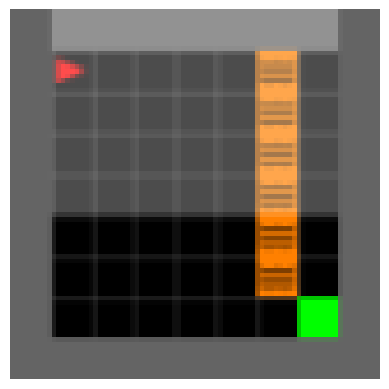

In [10]:
import matplotlib.pyplot as plt

# Plotting the image without the 4th dimension (assuming it's an alpha channel or similar)
plt.imshow(obs)
plt.axis('off')
plt.show()

In [11]:
# Set Replay Buffer
sub_buffer_size = 32
replay_buffer_config = {
    **hyper_parameters["replay_buffer_config"],
    "type": MultiAgentPrioritizedBlockReplayBuffer,
    "capacity": int(hyper_parameters["replay_buffer_config"]["capacity"]),
    "obs_space": env_example.observation_space,
    "action_space": env_example.action_space,
    "sub_buffer_size": sub_buffer_size,
    "worker_side_prioritization": False,
    "replay_buffer_shards_colocated_with_driver": True,
    "rollout_fragment_length": hyper_parameters["rollout_fragment_length"],
}
hyper_parameters["replay_buffer_config"] = replay_buffer_config
hyper_parameters["train_batch_size"] = int(hyper_parameters["train_batch_size"] / sub_buffer_size)
hyper_parameters["optimizer"] = {"num_replay_buffer_shards": 10}

# Set Trainer
trainer = ApexDDQNWithDPBER(config=hyper_parameters, env="MiniGrid")

2024-04-21 15:39:17,695	WARNING deprecation.py:50 -- DeprecationWarning: `rllib/algorithms/apex_dqn/` has been deprecated. Use `rllib_contrib/apex_dqn/` instead. This will raise an error in the future!
2024-04-21 15:39:17,697	WARNING deprecation.py:50 -- DeprecationWarning: `rllib/algorithms/simple_q/` has been deprecated. Use `rllib_contrib/simple_q/` instead. This will raise an error in the future!
2024-04-21 15:39:17,700	WARNING deprecation.py:50 -- DeprecationWarning: `algo = Algorithm(env='MiniGrid', ...)` has been deprecated. Use `algo = AlgorithmConfig().environment('MiniGrid').build()` instead. This will raise an error in the future!
/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/ray/rllib/utils/from_config.py:197: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of th

In [12]:
# Common setup
checkpoint_path = str(checkpoint_path)
# Save initial configuration
with open(os.path.join(checkpoint_path, "%s_config.pyl" % run_name), "wb") as f:
    _ = trainer.config.to_dict()
    pickle.dump(_, f)

In [13]:
mlflow_run = mlflow.start_run(run_name=run_name,
                              tags={"mlflow.user": "Local"})
# Log parameters
mlflow.log_params(hyper_parameters["replay_buffer_config"])
to_log = ['num_workers', 'double_q', 'dueling', 'lr', 'n_step', 'num_steps_sampled_before_learning_starts',
          'rollout_fragment_length', 'target_network_update_freq', 'train_batch_size', 'min_sample_timesteps_per_iteration']
mlflow.log_params(
    {key: hyper_parameters[key] for key in to_log})

In [14]:
keys_to_extract_sam = {"episode_reward_max", "episode_reward_min", "episode_reward_mean"}
keys_to_extract_sta = {"num_agent_steps_sampled", "num_agent_steps_trained"}
keys_to_extract_buf = {"add_batch_time_ms", "replay_time_ms", "update_priorities_time_ms"}

mlflow.pytorch.log_model(trainer.get_policy().model, run_name)
model_uri = "runs:/%s/model_name" % mlflow_run.info.run_id
mlflow.register_model(model_uri, run_name, tags={"episode" : 0})

/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO:botocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials
Successfully registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322'.
2024/04/21 15:39:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322, version 1
Created version '1' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322'.


<ModelVersion: aliases=[], creation_timestamp=1713710373211, current_stage='None', description='', last_updated_timestamp=1713710373211, name='APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322', run_id='0ddc2980d08c4191bd4adf64d1913c5b', run_link='', source='s3://jo-mlflow-ber/29/0ddc2980d08c4191bd4adf64d1913c5b/artifacts/model_name', status='READY', status_message='', tags={'episode': '0'}, user_id='', version='1'>

In [15]:
for i in tqdm(range(0, setting.log.max_run)):
    result = trainer.train()
    time_used = result["time_total_s"]
    try:
        sampler = result.get("sampler_results", {}).copy()
        eva = result.get("evaluation", {}).copy()
        info = result.get("info", {}).copy()
        sam = {key: sampler[key] for key in keys_to_extract_sam if key in sampler}
        sta = {key: info[key] for key in keys_to_extract_sta if key in info}
        buf = flatten_dict(info.get("replay_shard_0", {}))
        buf["est_size_bytes"] = buf["est_size_bytes"] * hyper_parameters["optimizer"]["num_replay_buffer_shards"]
        buf["est_size_gb"] = buf["est_size_bytes"] /1e9
        result['buffer'] = buf
        time_usage = info.get("learner", {}).get("time_usage", {})
        try:
            ex_info = {
                "reward_99" : calculate_adjusted_mean(result['hist_stats']['episode_reward']),
                "time_total_s": result['time_total_s']
            }
        except:
            ex_info = {}
        if eva:
            eva = {"eval_" + key: eva[key] for key in keys_to_extract_sam if key in eva}
        mlflow.log_metrics({**sam, **sta, **buf, **time_usage, **eva}, step=result["episodes_total"])
        if i % (setting.log.log * 50) == 0:
            trainer.save_checkpoint(checkpoint_path)
            mlflow.pytorch.log_model(trainer.get_policy().model, run_name)
            mlflow.register_model(model_uri, run_name, tags={
                "episode" : result["episodes_total"],
                "reward": sam["episode_reward_mean"],
            })
            mlflow.log_artifacts(log_path)
            mlflow.log_artifacts(checkpoint_path)
        if i % 10 == 0:
            tqdm.write("episode %d ; " % result["episodes_total"] +  " ".join(["%s : %f8" % (i, j)for i, j in sam.items()]))
    except FunctionTimedOut:
        tqdm.write("logging failed")
    except MlflowException:
        tqdm.write("logging failed")
    except ConnectionClosedError:
        tqdm.write("logging failed")
    with open(os.path.join(log_path, str(i) + ".json"), "w") as f:
        result["config"] = None
        json.dump(convert_np_arrays(result), f)
    if time_used >= setting.log.max_time:
        break

  0%|          | 0/10000 [00:00<?, ?it/s]

/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/ray/rllib/utils/metrics/window_stat.py:50: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(self.items[: self.count]))
/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
Registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322' already exists. Creating a new version of this model...
2024/04/21 15:40:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322, version 2
Created version '2' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322'.


episode 152 ; episode_reward_mean : 0.0000008 episode_reward_max : 0.0000008 episode_reward_min : 0.0000008
episode 824 ; episode_reward_mean : 0.0000008 episode_reward_max : 0.0000008 episode_reward_min : 0.0000008
episode 1449 ; episode_reward_mean : 0.0000008 episode_reward_max : 0.0000008 episode_reward_min : 0.0000008
episode 2080 ; episode_reward_mean : 0.0000008 episode_reward_max : 0.0000008 episode_reward_min : 0.0000008
episode 2705 ; episode_reward_mean : 0.0000008 episode_reward_max : 0.0000008 episode_reward_min : 0.0000008
episode 3338 ; episode_reward_mean : 0.0095838 episode_reward_max : 0.9583338 episode_reward_min : 0.0000008
episode 3970 ; episode_reward_mean : 0.0073338 episode_reward_max : 0.7333338 episode_reward_min : 0.0000008
episode 4618 ; episode_reward_mean : 0.0354448 episode_reward_max : 0.9583338 episode_reward_min : 0.0000008
episode 5274 ; episode_reward_mean : 0.0728068 episode_reward_max : 0.9583338 episode_reward_min : 0.0000008
episode 5968 ; episod

Registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322' already exists. Creating a new version of this model...
2024/04/21 23:37:47 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322, version 3
Created version '3' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322'.


episode 61418 ; episode_reward_mean : 0.8832468 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 64323 ; episode_reward_mean : 0.8716938 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 67318 ; episode_reward_mean : 0.8865348 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 70148 ; episode_reward_mean : 0.8496638 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 72975 ; episode_reward_mean : 0.8819548 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 75999 ; episode_reward_mean : 0.8836848 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 78910 ; episode_reward_mean : 0.8633708 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 81811 ; episode_reward_mean : 0.9006478 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 84672 ; episode_reward_mean : 0.9126428 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 87

Registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322' already exists. Creating a new version of this model...
2024/04/22 07:35:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322, version 4
Created version '4' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPBER_1713710322'.


episode 256459 ; episode_reward_mean : 0.9593438 episode_reward_max : 0.9638898 episode_reward_min : 0.8083338
episode 260766 ; episode_reward_mean : 0.9595298 episode_reward_max : 0.9638898 episode_reward_min : 0.8750008
episode 265081 ; episode_reward_mean : 0.9595368 episode_reward_max : 0.9638898 episode_reward_min : 0.8722228
episode 269435 ; episode_reward_mean : 0.9601898 episode_reward_max : 0.9638898 episode_reward_min : 0.9500008
episode 273745 ; episode_reward_mean : 0.9599338 episode_reward_max : 0.9638898 episode_reward_min : 0.8861118
episode 278071 ; episode_reward_mean : 0.9602708 episode_reward_max : 0.9638898 episode_reward_min : 0.9416678
episode 282422 ; episode_reward_mean : 0.9597298 episode_reward_max : 0.9638898 episode_reward_min : 0.9222228
episode 286772 ; episode_reward_mean : 0.9599408 episode_reward_max : 0.9638898 episode_reward_min : 0.9083338
episode 291117 ; episode_reward_mean : 0.9599888 episode_reward_max : 0.9638898 episode_reward_min : 0.9111118
e

Exception ignored in: <function tqdm.__del__ at 0x7fdb60518a60>
Traceback (most recent call last):
  File "/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/tqdm/std.py", line 1147, in __del__
    def __del__(self):
KeyboardInterrupt: 

KeyboardInterrupt



In [ ]:
mlflow.log_artifacts(log_path)
mlflow.log_artifacts(checkpoint_path)
mlflow.end_run()